# 1단계: 패키지 설치 및 임포트


In [ ]:
# 필수 패키지 설치
!pip install transformers torch torchvision torchaudio
!pip install scikit-learn pandas numpy matplotlib seaborn

# 패키지 임포트
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')
print("패키지 설치 및 임포트 완료!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

# 2단계: GPU 설정 확인

In [20]:
# GPU 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

if torch.cuda.is_available():
    print(f"GPU 디바이스: {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("GPU를 사용할 수 없습니다. CPU를 사용합니다.")

사용 디바이스: cpu
GPU를 사용할 수 없습니다. CPU를 사용합니다.


# 3단계: BERT 모델 로딩

In [5]:
# 한국어 BERT 모델 로딩
model_name = 'klue/bert-base'
print(f"BERT 모델 로딩 중: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)
bert_model.to(device)
bert_model.eval()

print("BERT 모델 로딩 완료!")
print(f"토크나이저 어휘 크기: {len(tokenizer)}")

BERT 모델 로딩 중: klue/bert-base


tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

BERT 모델 로딩 완료!
토크나이저 어휘 크기: 32000


# 4단계: 샘플 데이터 생성


In [6]:
# 테스트용 샘플 데이터 생성
def create_sample_data(n_samples=100):
    np.random.seed(42)

    # 이탈 고객 녹취록 패턴
    churn_patterns = [
        "해지하고 싶습니다. 서비스가 마음에 들지 않아요.",
        "요금이 너무 비싸서 다른 회사로 옮기려고 해요.",
        "서비스 품질이 떨어져서 불만이 많아요.",
        "계약을 취소하고 더 이상 사용하지 않겠습니다.",
        "경쟁사 서비스가 더 좋은 것 같아요.",
        "고객 서비스가 너무 불친절해서 그만두고 싶어요.",
        "기대했던 것보다 서비스가 별로예요.",
        "가격 대비 만족도가 낮아서 해지하려고 해요."
    ]

    # 유지 고객 녹취록 패턴
    retain_patterns = [
        "서비스가 정말 만족스러워요. 계속 이용하고 싶습니다.",
        "좋은 서비스 덕분에 편리하게 사용하고 있어요.",
        "가격 대비 서비스 품질이 뛰어나네요.",
        "친절한 상담과 좋은 서비스 감사합니다.",
        "앞으로도 계속 이용할 예정입니다.",
        "추천하고 싶을 정도로 서비스가 좋아요.",
        "만족하며 사용하고 있습니다. 감사해요.",
        "서비스 품질이 우수해서 신뢰가 갑니다."
    ]

    transcripts = []
    labels = []

    # 이탈 고객 데이터 생성 (50%)
    n_churn = n_samples // 2
    for _ in range(n_churn):
        transcript = np.random.choice(churn_patterns)
        transcripts.append(transcript)
        labels.append(1)  # 이탈

    # 유지 고객 데이터 생성 (50%)
    n_retain = n_samples - n_churn
    for _ in range(n_retain):
        transcript = np.random.choice(retain_patterns)
        transcripts.append(transcript)
        labels.append(0)  # 유지

    # 추가 특성 생성 (고객 정보)
    additional_features = pd.DataFrame({
        'customer_age': np.random.randint(20, 70, n_samples),
        'service_duration_months': np.random.randint(1, 60, n_samples),
        'monthly_bill': np.random.randint(30000, 150000, n_samples),
        'complaint_count': np.random.randint(0, 10, n_samples),
        'customer_grade': np.random.choice(['Bronze', 'Silver', 'Gold', 'Platinum'], n_samples)
    })

    return transcripts, additional_features, labels

# 샘플 데이터 생성
transcripts, additional_features_df, labels = create_sample_data(n_samples=200)

print("샘플 데이터 생성 완료!")
print(f"- 총 샘플 수: {len(transcripts)}")
print(f"- 이탈 고객 수: {sum(labels)}")
print(f"- 유지 고객 수: {len(labels) - sum(labels)}")
print(f"- 추가 특성: {list(additional_features_df.columns)}")

# 샘플 데이터 미리보기
print("\n=== 샘플 녹취록 미리보기 ===")
for i in range(3):
    status = "이탈" if labels[i] == 1 else "유지"
    print(f"{i+1}. [{status}] {transcripts[i]}")

print("\n=== 추가 특성 미리보기 ===")
print(additional_features_df.head())


샘플 데이터 생성 완료!
- 총 샘플 수: 200
- 이탈 고객 수: 100
- 유지 고객 수: 100
- 추가 특성: ['customer_age', 'service_duration_months', 'monthly_bill', 'complaint_count', 'customer_grade']

=== 샘플 녹취록 미리보기 ===
1. [이탈] 기대했던 것보다 서비스가 별로예요.
2. [이탈] 계약을 취소하고 더 이상 사용하지 않겠습니다.
3. [이탈] 경쟁사 서비스가 더 좋은 것 같아요.

=== 추가 특성 미리보기 ===
   customer_age  service_duration_months  monthly_bill  complaint_count  \
0            51                       19        140226                6   
1            58                        4        130793                2   
2            68                       35         39823                1   
3            51                       49         90160                9   
4            23                       17         71975                3   

  customer_grade  
0           Gold  
1       Platinum  
2         Silver  
3           Gold  
4           Gold  


# 5단계: BERT 임베딩 추출 함수 정의

In [21]:
def extract_bert_embeddings(texts, batch_size=8):
    """
    텍스트를 BERT로 임베딩 추출
    """
    embeddings = []
    total_batches = (len(texts) + batch_size - 1) // batch_size

    print(f"총 {len(texts)}개 텍스트를 {total_batches}개 배치로 처리합니다.")

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_num = i // batch_size + 1
            print(f"배치 처리 중: {batch_num}/{total_batches}")

            batch_texts = texts[i:i+batch_size]

            # 토큰화
            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt'
            )

            # GPU로 이동
            input_ids = encoded['input_ids'].to(device)
            attention_mask = encoded['attention_mask'].to(device)

            try:
                # BERT 임베딩 추출
                outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)

                # [CLS] 토큰의 임베딩 사용 (문장 전체 표현)
                cls_embeddings = outputs.last_hidden_state[:, 0, :]  # (batch_size, 768)

                # 768차원을 512차원으로 축소
                reduced_embeddings = cls_embeddings[:, :512]

                embeddings.append(reduced_embeddings.cpu().numpy())

            except RuntimeError as e:
                if "out of memory" in str(e):
                    print("GPU 메모리 부족! 배치 크기를 줄여주세요.")
                    torch.cuda.empty_cache()
                    raise e
                else:
                    raise e

    final_embeddings = np.vstack(embeddings)
    print(f"BERT 임베딩 추출 완료! 형태: {final_embeddings.shape}")
    return final_embeddings

# 6단계: BERT 임베딩 추출 실행

In [8]:
print("BERT 임베딩 추출 시작...")
bert_embeddings = extract_bert_embeddings(transcripts)

print(f"BERT 임베딩 형태: {bert_embeddings.shape}")
print(f"임베딩 통계:")
print(f"- 평균: {bert_embeddings.mean():.6f}")
print(f"- 표준편차: {bert_embeddings.std():.6f}")
print(f"- 최솟값: {bert_embeddings.min():.6f}")
print(f"- 최댓값: {bert_embeddings.max():.6f}")

BERT 임베딩 추출 시작...
총 200개 텍스트를 25개 배치로 처리합니다.
배치 처리 중: 1/25
배치 처리 중: 2/25
배치 처리 중: 3/25
배치 처리 중: 4/25
배치 처리 중: 5/25
배치 처리 중: 6/25
배치 처리 중: 7/25
배치 처리 중: 8/25
배치 처리 중: 9/25
배치 처리 중: 10/25
배치 처리 중: 11/25
배치 처리 중: 12/25
배치 처리 중: 13/25
배치 처리 중: 14/25
배치 처리 중: 15/25
배치 처리 중: 16/25
배치 처리 중: 17/25
배치 처리 중: 18/25
배치 처리 중: 19/25
배치 처리 중: 20/25
배치 처리 중: 21/25
배치 처리 중: 22/25
배치 처리 중: 23/25
배치 처리 중: 24/25
배치 처리 중: 25/25
BERT 임베딩 추출 완료! 형태: (200, 512)
BERT 임베딩 형태: (200, 512)
임베딩 통계:
- 평균: 0.018799
- 표준편차: 0.796255
- 최솟값: -3.182763
- 최댓값: 4.653260


# 7단계: 추가 특성 전처리


In [9]:
def preprocess_additional_features(df):
    """추가 특성 전처리"""
    processed_features = []
    label_encoders = {}

    print("추가 특성 전처리 중...")

    for column in df.columns:
        print(f"처리 중: {column}")

        if df[column].dtype == 'object':
            # 범주형 변수 인코딩
            le = LabelEncoder()
            encoded = le.fit_transform(df[column].fillna('Unknown'))
            processed_features.append(encoded.reshape(-1, 1))
            label_encoders[column] = le
            print(f"  - 범주형 변수, 고유값 수: {len(le.classes_)}")
        else:
            # 수치형 변수
            values = df[column].fillna(df[column].median()).values
            processed_features.append(values.reshape(-1, 1))
            print(f"  - 수치형 변수, 범위: [{values.min():.1f}, {values.max():.1f}]")

    if processed_features:
        result = np.hstack(processed_features)
        print(f"추가 특성 전처리 완료! 형태: {result.shape}")
        return result, label_encoders
    else:
        return np.array([]).reshape(len(df), 0), label_encoders

# 추가 특성 전처리 실행
additional_features, label_encoders = preprocess_additional_features(additional_features_df)

print(f"\n추가 특성 통계:")
print(f"- 형태: {additional_features.shape}")
print(f"- 범위: [{additional_features.min():.2f}, {additional_features.max():.2f}]")

추가 특성 전처리 중...
처리 중: customer_age
  - 수치형 변수, 범위: [20.0, 69.0]
처리 중: service_duration_months
  - 수치형 변수, 범위: [1.0, 58.0]
처리 중: monthly_bill
  - 수치형 변수, 범위: [30412.0, 149180.0]
처리 중: complaint_count
  - 수치형 변수, 범위: [0.0, 9.0]
처리 중: customer_grade
  - 범주형 변수, 고유값 수: 4
추가 특성 전처리 완료! 형태: (200, 5)

추가 특성 통계:
- 형태: (200, 5)
- 범위: [0.00, 149180.00]


# 8단계: 모든 특성 결합

In [10]:
print("특성 결합 중...")

# BERT 임베딩과 추가 특성 결합
if additional_features.shape[1] > 0:
    combined_features = np.hstack([bert_embeddings, additional_features])
    print(f"결합된 특성 형태: {combined_features.shape}")
    print(f"- BERT 임베딩: {bert_embeddings.shape[1]}차원")
    print(f"- 추가 특성: {additional_features.shape[1]}차원")
else:
    combined_features = bert_embeddings
    print(f"BERT 임베딩만 사용: {combined_features.shape}")

# 특성 정보 출력
print(f"\n최종 특성 통계:")
print(f"- 샘플 수: {combined_features.shape[0]}")
print(f"- 특성 수: {combined_features.shape[1]}")
print(f"- 평균: {combined_features.mean():.6f}")
print(f"- 표준편차: {combined_features.std():.6f}")

특성 결합 중...
결합된 특성 형태: (200, 517)
- BERT 임베딩: 512차원
- 추가 특성: 5차원

최종 특성 통계:
- 샘플 수: 200
- 특성 수: 517
- 평균: 171.702215
- 표준편차: 4172.238296


# 9단계: 데이터 분할 및 스케일링

In [11]:
# 특성과 레이블 준비
X = combined_features
y = np.array(labels)

print(f"데이터 분할 전:")
print(f"- 전체 샘플 수: {len(X)}")
print(f"- 이탈 고객 수: {sum(y)} ({sum(y)/len(y)*100:.1f}%)")
print(f"- 유지 고객 수: {len(y) - sum(y)} ({(len(y)-sum(y))/len(y)*100:.1f}%)")

# 훈련/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n데이터 분할 후:")
print(f"- 훈련 세트: {len(X_train)}개 (이탈: {sum(y_train)}개)")
print(f"- 테스트 세트: {len(X_test)}개 (이탈: {sum(y_test)}개)")

# 특성 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n스케일링 후 통계:")
print(f"- 훈련 세트 평균: {X_train_scaled.mean():.6f}")
print(f"- 훈련 세트 표준편차: {X_train_scaled.std():.6f}")
print(f"- 테스트 세트 평균: {X_test_scaled.mean():.6f}")
print(f"- 테스트 세트 표준편차: {X_test_scaled.std():.6f}")


데이터 분할 전:
- 전체 샘플 수: 200
- 이탈 고객 수: 100 (50.0%)
- 유지 고객 수: 100 (50.0%)

데이터 분할 후:
- 훈련 세트: 160개 (이탈: 80개)
- 테스트 세트: 40개 (이탈: 20개)

스케일링 후 통계:
- 훈련 세트 평균: -0.000000
- 훈련 세트 표준편차: 1.000000
- 테스트 세트 평균: 0.004164
- 테스트 세트 표준편차: 0.987952


# 10단계: Random Forest 모델 훈련

In [13]:
print("Random Forest 모델 훈련 시작...")

# Random Forest 분류기 생성
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# 모델 훈련
rf_classifier.fit(X_train_scaled, y_train)

print("Random Forest 모델 훈련 완료!")

# 훈련 세트 성능
train_pred = rf_classifier.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"훈련 세트 정확도: {train_accuracy:.4f}")

# 테스트 세트 예측
test_pred = rf_classifier.predict(X_test_scaled)
test_pred_proba = rf_classifier.predict_proba(X_test_scaled)[:, 1]

# 테스트 세트 성능
test_accuracy = accuracy_score(y_test, test_pred)
auc_score = roc_auc_score(y_test, test_pred_proba)

print(f"\n=== Random Forest 모델 성능 ===")
print(f"테스트 세트 정확도: {test_accuracy:.4f}")
print(f"ROC-AUC 점수: {auc_score:.4f}")


Random Forest 모델 훈련 시작...
Random Forest 모델 훈련 완료!
훈련 세트 정확도: 1.0000

=== Random Forest 모델 성능 ===
테스트 세트 정확도: 1.0000
ROC-AUC 점수: 1.0000


# 11단계: 모델 평가 상세 결과

=== 상세 분류 보고서 ===
              precision    recall  f1-score   support

          유지       1.00      1.00      1.00        20
          이탈       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


=== 혼동 행렬 ===
[[20  0]
 [ 0 20]]


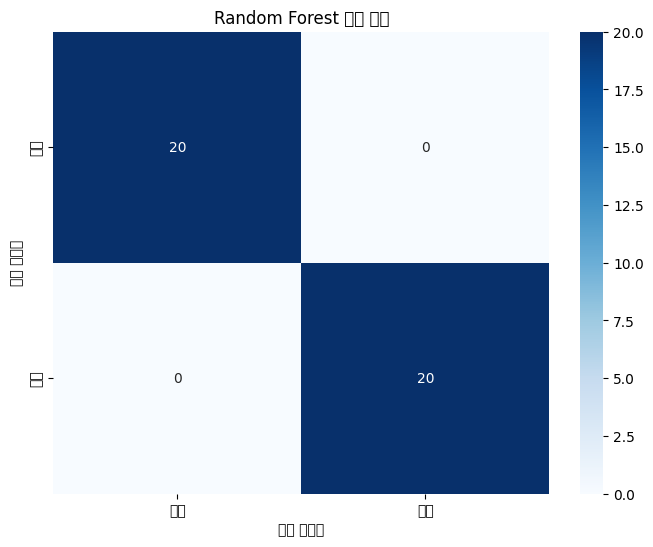

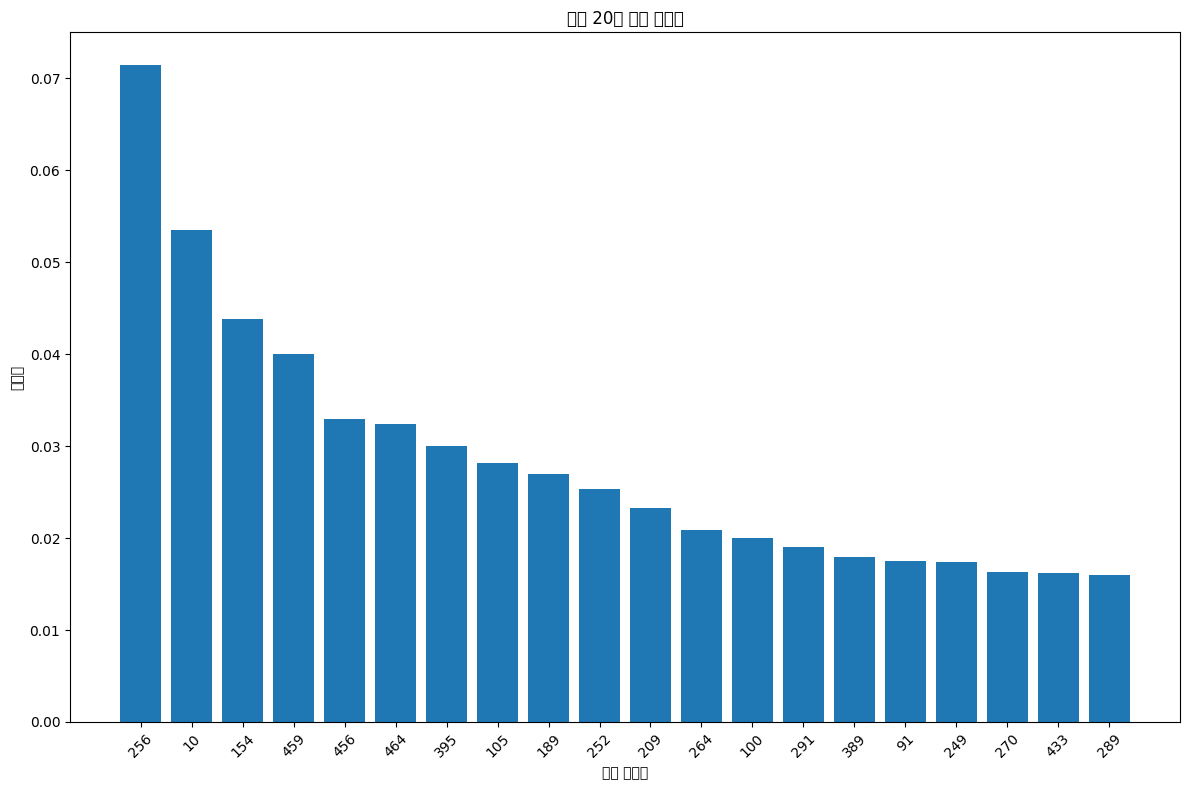

가장 중요한 특성 인덱스: [256  10 154 459 456]


In [22]:
print("=== 상세 분류 보고서 ===")
print(classification_report(y_test, test_pred, target_names=['유지', '이탈']))

print("\n=== 혼동 행렬 ===")
cm = confusion_matrix(y_test, test_pred)
print(cm)

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['유지', '이탈'], yticklabels=['유지', '이탈'])
plt.title('Random Forest 혼동 행렬')
plt.ylabel('실제 레이블')
plt.xlabel('예측 레이블')
plt.show()

# 특성 중요도 시각화
feature_importance = rf_classifier.feature_importances_
top_features = 20

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance)[::-1][:top_features]
plt.title(f'상위 {top_features}개 특성 중요도')
plt.bar(range(top_features), feature_importance[indices])
plt.xlabel('특성 인덱스')
plt.ylabel('중요도')
plt.xticks(range(top_features), indices, rotation=45)
plt.tight_layout()
plt.show()

print(f"가장 중요한 특성 인덱스: {indices[:5]}")

# 12단계: Logistic Regression 모델 비교

In [15]:
print("Logistic Regression 모델 훈련 시작...")

# Logistic Regression 분류기 생성
lr_classifier = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1
)

# 모델 훈련
lr_classifier.fit(X_train_scaled, y_train)

# 예측
lr_test_pred = lr_classifier.predict(X_test_scaled)
lr_test_pred_proba = lr_classifier.predict_proba(X_test_scaled)[:, 1]

# 성능 평가
lr_accuracy = accuracy_score(y_test, lr_test_pred)
lr_auc = roc_auc_score(y_test, lr_test_pred_proba)

print(f"\n=== Logistic Regression 모델 성능 ===")
print(f"테스트 세트 정확도: {lr_accuracy:.4f}")
print(f"ROC-AUC 점수: {lr_auc:.4f}")

# 두 모델 성능 비교
print(f"\n=== 모델 성능 비교 ===")
print(f"Random Forest    - 정확도: {test_accuracy:.4f}, AUC: {auc_score:.4f}")
print(f"Logistic Regression - 정확도: {lr_accuracy:.4f}, AUC: {lr_auc:.4f}")

Logistic Regression 모델 훈련 시작...

=== Logistic Regression 모델 성능 ===
테스트 세트 정확도: 1.0000
ROC-AUC 점수: 1.0000

=== 모델 성능 비교 ===
Random Forest    - 정확도: 1.0000, AUC: 1.0000
Logistic Regression - 정확도: 1.0000, AUC: 1.0000


# 13단계: 새로운 데이터로 예측 테스트

In [16]:
print("새로운 데이터로 예측 테스트...")

# 테스트용 새로운 녹취록 데이터
test_transcripts = [
    "해지하고 싶어요. 서비스가 정말 별로예요.",
    "정말 만족합니다. 계속 이용할게요.",
    "요금이 비싸서 다른 곳으로 옮기려고 해요.",
    "서비스 품질이 우수해서 추천하고 싶어요.",
    "불만이 많아서 계약을 취소하고 싶습니다."
]

# 테스트용 추가 특성
test_features_df = pd.DataFrame({
    'customer_age': [30, 45, 25, 55, 35],
    'service_duration_months': [6, 24, 3, 36, 12],
    'monthly_bill': [80000, 60000, 100000, 90000, 70000],
    'complaint_count': [3, 0, 2, 0, 4],
    'customer_grade': ['Bronze', 'Gold', 'Silver', 'Platinum', 'Bronze']
})

print("테스트 데이터:")
for i, transcript in enumerate(test_transcripts):
    print(f"{i+1}. {transcript}")

# 새로운 데이터 전처리
print("\n새로운 데이터 전처리 중...")

# BERT 임베딩 추출
test_bert_embeddings = extract_bert_embeddings(test_transcripts)

# 추가 특성 전처리 (기존 인코더 사용)
test_additional_features = []
for column in test_features_df.columns:
    if test_features_df[column].dtype == 'object':
        # 기존 레이블 인코더 사용
        encoded = label_encoders[column].transform(test_features_df[column].fillna('Unknown'))
        test_additional_features.append(encoded.reshape(-1, 1))
    else:
        values = test_features_df[column].fillna(test_features_df[column].median()).values
        test_additional_features.append(values.reshape(-1, 1))

test_additional_features = np.hstack(test_additional_features)

# 특성 결합
test_combined_features = np.hstack([test_bert_embeddings, test_additional_features])

# 스케일링
test_scaled_features = scaler.transform(test_combined_features)

print(f"테스트 데이터 전처리 완료! 형태: {test_scaled_features.shape}")

새로운 데이터로 예측 테스트...
테스트 데이터:
1. 해지하고 싶어요. 서비스가 정말 별로예요.
2. 정말 만족합니다. 계속 이용할게요.
3. 요금이 비싸서 다른 곳으로 옮기려고 해요.
4. 서비스 품질이 우수해서 추천하고 싶어요.
5. 불만이 많아서 계약을 취소하고 싶습니다.

새로운 데이터 전처리 중...
총 5개 텍스트를 1개 배치로 처리합니다.
배치 처리 중: 1/1
BERT 임베딩 추출 완료! 형태: (5, 512)
테스트 데이터 전처리 완료! 형태: (5, 517)


# 14단계: 최종 예측 결과

=== 최종 예측 결과 ===


1. 녹취록: '해지하고 싶어요. 서비스가 정말 별로예요.'
   고객 정보: 30세, 6개월 이용, Bronze 등급
   Random Forest: 이탈 예상 (확률: 0.910)
   Logistic Regression: 이탈 예상 (확률: 1.000)

2. 녹취록: '정말 만족합니다. 계속 이용할게요.'
   고객 정보: 45세, 24개월 이용, Gold 등급
   Random Forest: 유지 예상 (확률: 0.090)
   Logistic Regression: 유지 예상 (확률: 0.000)

3. 녹취록: '요금이 비싸서 다른 곳으로 옮기려고 해요.'
   고객 정보: 25세, 3개월 이용, Silver 등급
   Random Forest: 이탈 예상 (확률: 0.900)
   Logistic Regression: 이탈 예상 (확률: 0.999)

4. 녹취록: '서비스 품질이 우수해서 추천하고 싶어요.'
   고객 정보: 55세, 36개월 이용, Platinum 등급
   Random Forest: 유지 예상 (확률: 0.130)
   Logistic Regression: 유지 예상 (확률: 0.001)

5. 녹취록: '불만이 많아서 계약을 취소하고 싶습니다.'
   고객 정보: 35세, 12개월 이용, Bronze 등급
   Random Forest: 이탈 예상 (확률: 0.660)
   Logistic Regression: 이탈 예상 (확률: 0.998)


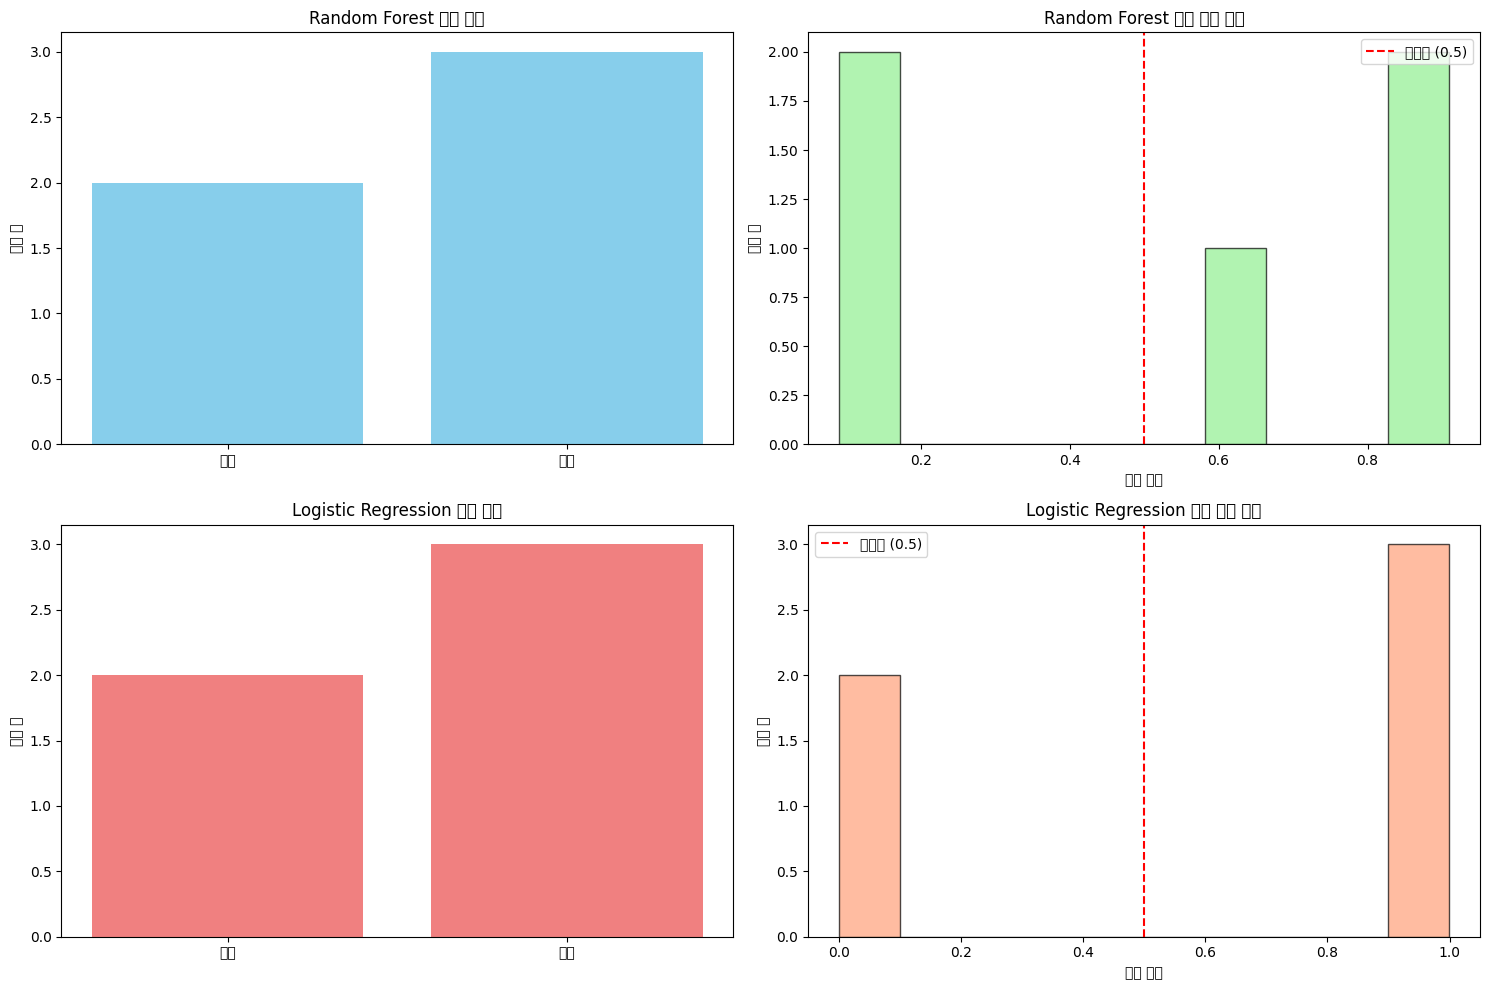


모든 단계 완료! 모델 훈련 및 예측이 성공적으로 완료되었습니다.


In [17]:
# Random Forest로 예측
rf_predictions = rf_classifier.predict(test_scaled_features)
rf_probabilities = rf_classifier.predict_proba(test_scaled_features)[:, 1]

# Logistic Regression으로 예측
lr_predictions = lr_classifier.predict(test_scaled_features)
lr_probabilities = lr_classifier.predict_proba(test_scaled_features)[:, 1]

print("=== 최종 예측 결과 ===")
print("\n" + "="*80)

for i in range(len(test_transcripts)):
    print(f"\n{i+1}. 녹취록: '{test_transcripts[i]}'")
    print(f"   고객 정보: {test_features_df.iloc[i]['customer_age']}세, " +
          f"{test_features_df.iloc[i]['service_duration_months']}개월 이용, " +
          f"{test_features_df.iloc[i]['customer_grade']} 등급")

    rf_status = "이탈 예상" if rf_predictions[i] == 1 else "유지 예상"
    lr_status = "이탈 예상" if lr_predictions[i] == 1 else "유지 예상"

    print(f"   Random Forest: {rf_status} (확률: {rf_probabilities[i]:.3f})")
    print(f"   Logistic Regression: {lr_status} (확률: {lr_probabilities[i]:.3f})")

# 예측 결과 시각화
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Random Forest 예측 분포
rf_unique, rf_counts = np.unique(rf_predictions, return_counts=True)
labels = ['유지', '이탈']
ax1.bar([labels[i] for i in rf_unique], rf_counts, color='skyblue')
ax1.set_title('Random Forest 예측 분포')
ax1.set_ylabel('고객 수')

# Random Forest 확률 분포
ax2.hist(rf_probabilities, bins=10, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.set_title('Random Forest 이탈 확률 분포')
ax2.set_xlabel('이탈 확률')
ax2.set_ylabel('고객 수')
ax2.axvline(x=0.5, color='red', linestyle='--', label='임계점 (0.5)')
ax2.legend()

# Logistic Regression 예측 분포
lr_unique, lr_counts = np.unique(lr_predictions, return_counts=True)
ax3.bar([labels[i] for i in lr_unique], lr_counts, color='lightcoral')
ax3.set_title('Logistic Regression 예측 분포')
ax3.set_ylabel('고객 수')

# Logistic Regression 확률 분포
ax4.hist(lr_probabilities, bins=10, alpha=0.7, color='lightsalmon', edgecolor='black')
ax4.set_title('Logistic Regression 이탈 확률 분포')
ax4.set_xlabel('이탈 확률')
ax4.set_ylabel('고객 수')
ax4.axvline(x=0.5, color='red', linestyle='--', label='임계점 (0.5)')
ax4.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("모든 단계 완료! 모델 훈련 및 예측이 성공적으로 완료되었습니다.")
print("="*80)